# MASTERCLASS — FORECASTING 
## Autor: Josef  Rodríguez 

Este notebook integra **teoría + práctica** en un flujo profesional con 2 datasets:

- **Dataset simple (Airline, mensual):** tendencia + estacionalidad fuerte → modelos clásicos (ETS/SARIMA) + baselines.
- **Dataset complejo (Bitcoin, diario):** alta volatilidad → modelamos **retornos** y aplicamos ML tabular + walk-forward + backtest didáctico.

---

## Principios industriales (en 3 bullets)
1. **Split temporal** (no random split).
2. **Baseline primero** (si no supera Seasonal Naive, no está listo).
3. **Sin leakage** (features solo con información disponible hasta \(t\)).

# Introducción a Forecasting

## ¿Qué es Forecasting?

El forecasting (pronóstico) es el proceso de estimar valores futuros de una variable utilizando información histórica.

Formalmente, queremos estimar:

$$
y_{t+h} = f(y_t, y_{t-1}, y_{t-2}, ..., X_t)
$$

donde:

- $y_{t+h}$ = valor futuro en horizonte $h$
- $f$ = modelo predictivo
- $X_t$ = variables externas (si existen)

---

## ¿Para qué se usa?

Forecasting es fundamental en:

- Finanzas → precios, retornos, riesgo
- Retail → demanda, inventarios
- Energía → consumo eléctrico
- Transporte → tráfico
- Bancos → mora futura, flujo de caja

---

## Componentes de una Serie Temporal

Una serie temporal puede descomponerse como:

Modelo aditivo:

$$
y_t = T_t + S_t + E_t
$$

Modelo multiplicativo:

$$
y_t = T_t \times S_t \times E_t
$$

donde:

- $T_t$ = Tendencia
- $S_t$ = Estacionalidad
- $E_t$ = Ruido

---

## Diferencia con Machine Learning tradicional

En ML clásico:

- Los datos son independientes (i.i.d.)

En forecasting:

- Existe dependencia temporal
- No se puede hacer random split
- El orden importa

Split correcto:

$$
Train: t_1 \rightarrow t_k
$$

$$
Test: t_{k+1} \rightarrow t_n
$$

---

## Tipos de Forecasting

1. Univariado → solo usa la historia de la serie
2. Multivariado → usa variables externas
3. Corto plazo vs largo plazo
4. Determinístico vs probabilístico (intervalos de confianza)

---

## Flujo Profesional en Industria

1. Análisis exploratorio temporal
2. Baseline obligatorio
3. Modelo avanzado
4. Walk-forward validation
5. Métricas comparativas
6. Intervalos de predicción
7. Monitoreo en producción

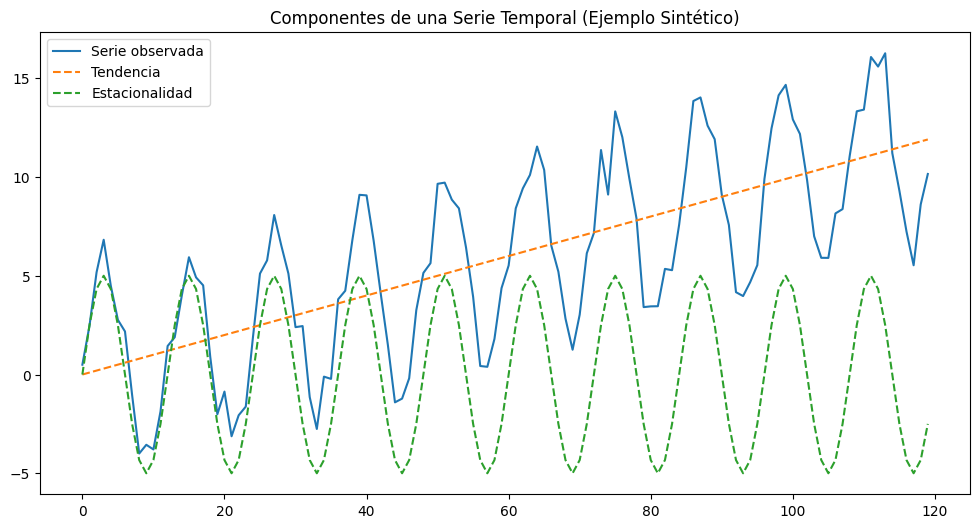

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
t = np.arange(0, 120)

trend = 0.1 * t
seasonality = 5 * np.sin(2 * np.pi * t / 12)
noise = np.random.normal(0, 1, len(t))

y = trend + seasonality + noise

plt.figure(figsize=(12,6))
plt.plot(t, y, label="Serie observada")
plt.plot(t, trend, label="Tendencia", linestyle="--")
plt.plot(t, seasonality, label="Estacionalidad", linestyle="--")
plt.title("Componentes de una Serie Temporal (Ejemplo Sintético)")
plt.legend()
plt.show()

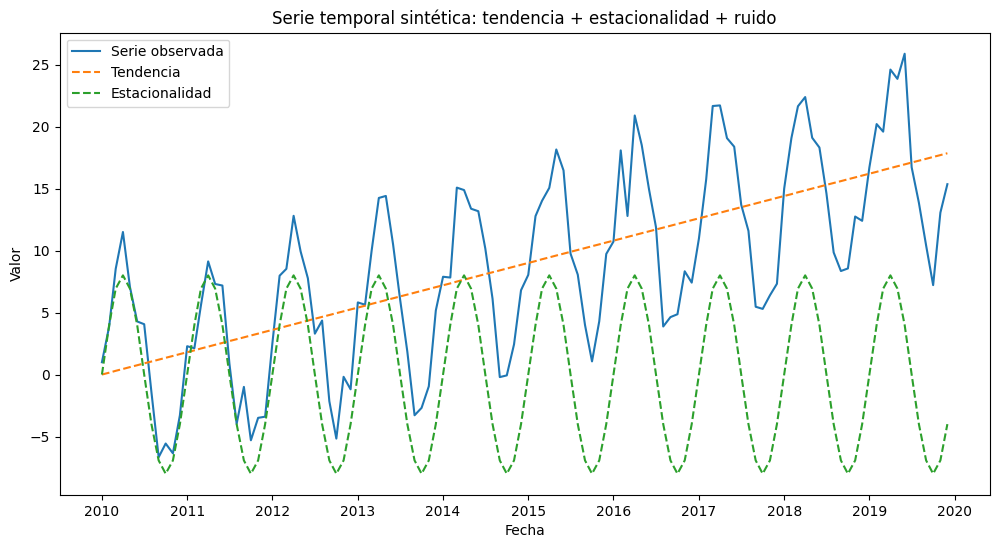

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Serie sintética mensual (120 meses)
t = np.arange(0, 120)
trend = 0.15 * t
seasonality = 8 * np.sin(2 * np.pi * t / 12)
noise = np.random.normal(0, 2.0, size=len(t))

y = trend + seasonality + noise

idx = pd.date_range("2010-01-01", periods=len(t), freq="MS")
ts = pd.Series(y, index=idx, name="y")

plt.figure(figsize=(12,6))
plt.plot(ts.index, ts.values, label="Serie observada")
plt.plot(ts.index, trend, linestyle="--", label="Tendencia")
plt.plot(ts.index, seasonality, linestyle="--", label="Estacionalidad")
plt.title("Serie temporal sintética: tendencia + estacionalidad + ruido")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.show()

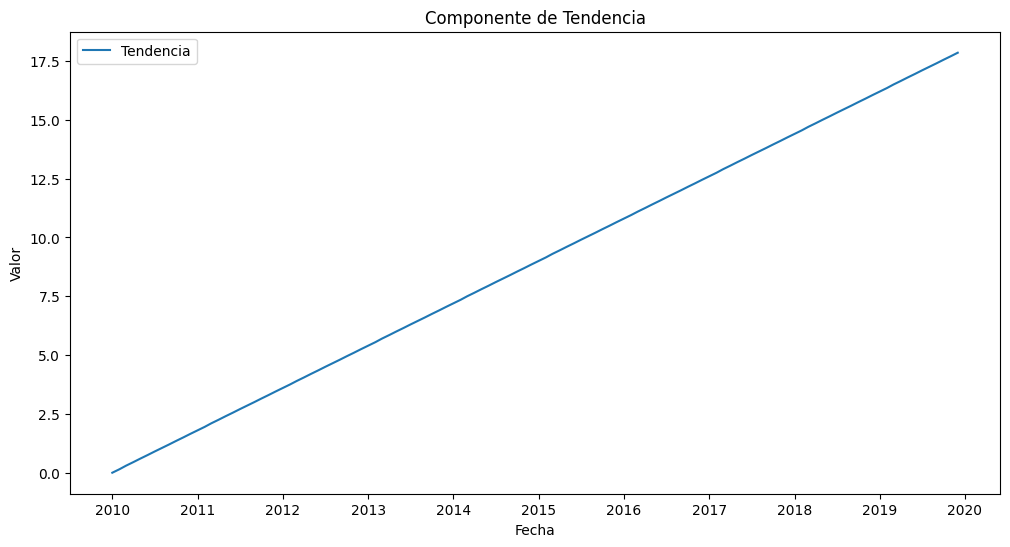

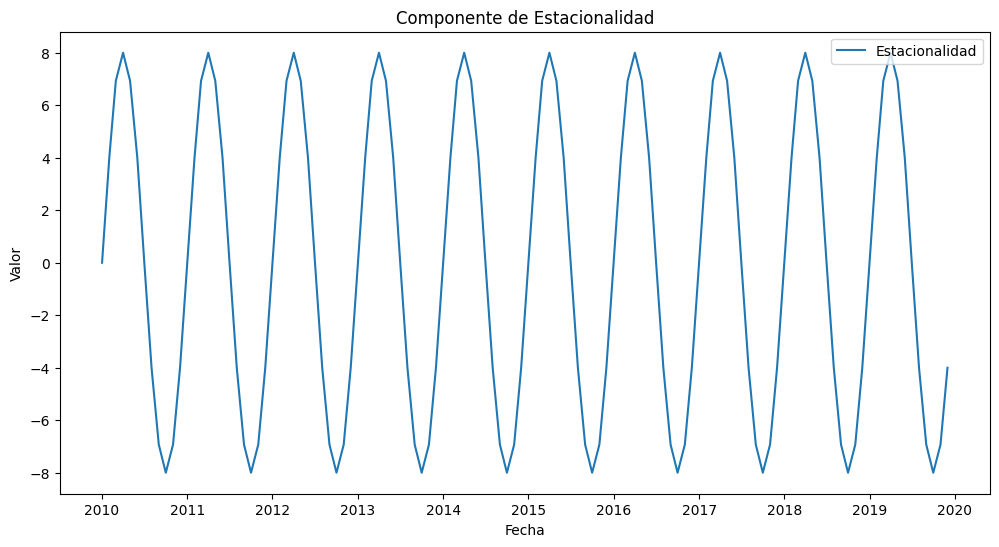

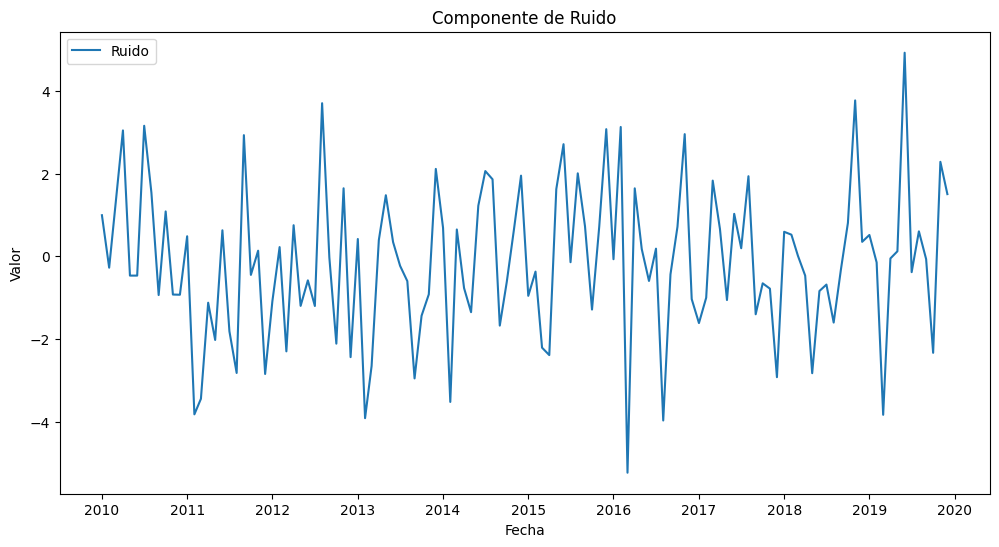

In [3]:
plt.figure(figsize=(12,6))
plt.plot(ts.index, trend, label="Tendencia")
plt.title("Componente de Tendencia")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(ts.index, seasonality, label="Estacionalidad")
plt.title("Componente de Estacionalidad")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(ts.index, noise, label="Ruido")
plt.title("Componente de Ruido")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.show()

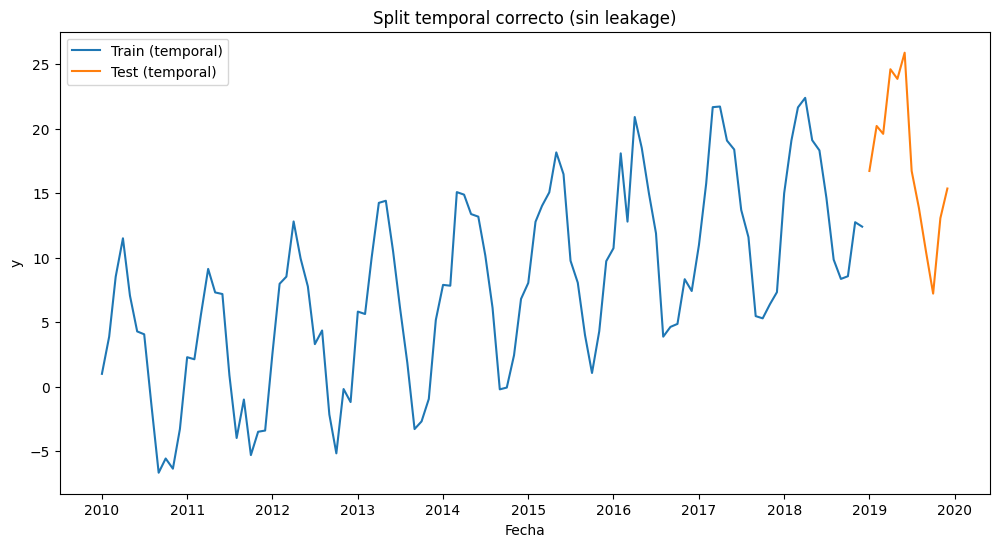

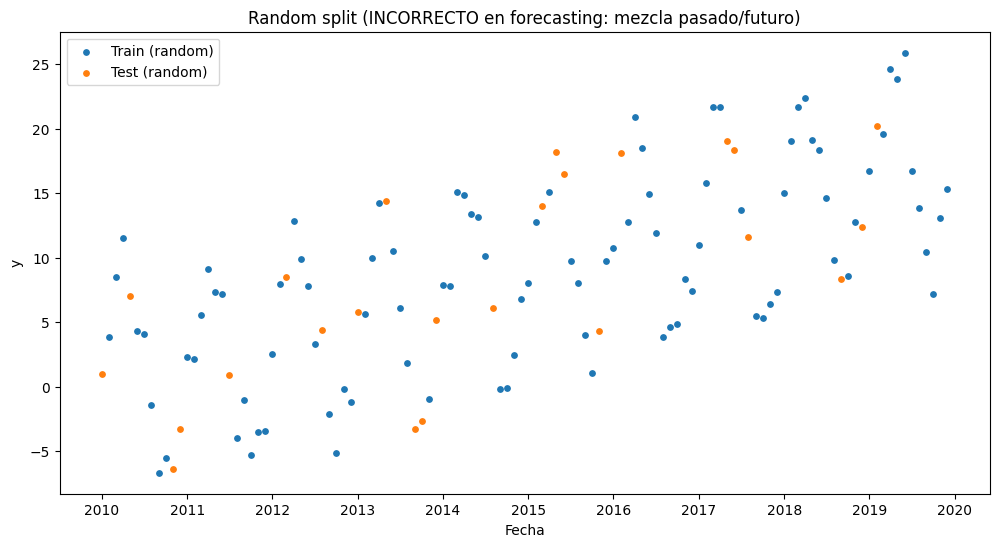

In [4]:
from sklearn.model_selection import train_test_split

# Split temporal (correcto)
H = 12
train_ts = ts.iloc[:-H]
test_ts = ts.iloc[-H:]

plt.figure(figsize=(12,6))
plt.plot(train_ts.index, train_ts.values, label="Train (temporal)")
plt.plot(test_ts.index, test_ts.values, label="Test (temporal)")
plt.title("Split temporal correcto (sin leakage)")
plt.xlabel("Fecha")
plt.ylabel("y")
plt.legend()
plt.show()

# Random split (incorrecto para series)
df_tmp = ts.reset_index()
df_tmp.columns = ["date","y"]
train_r, test_r = train_test_split(df_tmp, test_size=0.2, random_state=42, shuffle=True)

plt.figure(figsize=(12,6))
plt.scatter(train_r["date"], train_r["y"], s=15, label="Train (random)")
plt.scatter(test_r["date"], test_r["y"], s=15, label="Test (random)")
plt.title("Random split (INCORRECTO en forecasting: mezcla pasado/futuro)")
plt.xlabel("Fecha")
plt.ylabel("y")
plt.legend()
plt.show()

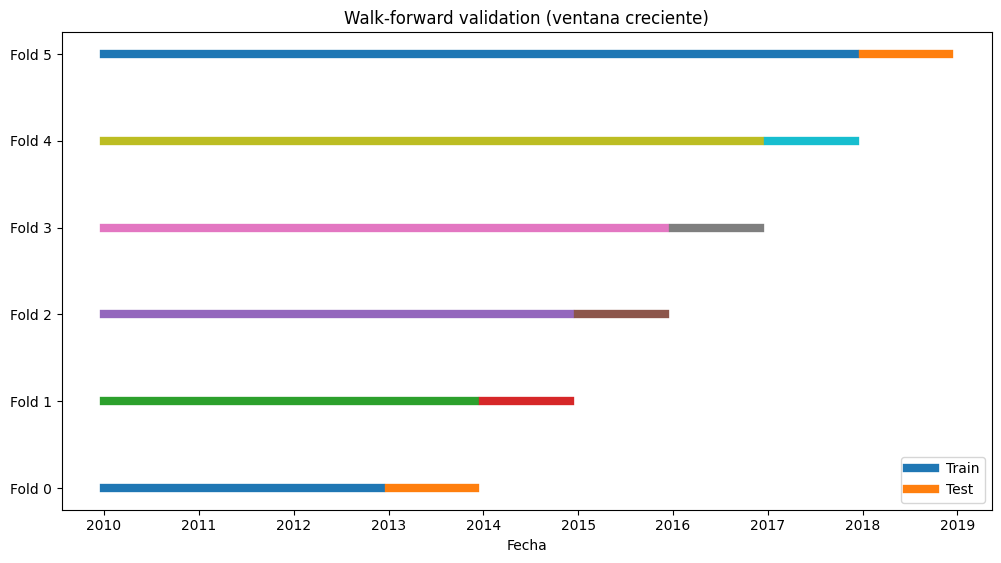

In [5]:
def plot_walk_forward_splits(series: pd.Series, n_splits=5, test_size=12, min_train=36):
    """
    Visualiza walk-forward (ventana creciente).
    n_splits: cuántos folds mostrar
    test_size: tamaño del bloque test por fold
    min_train: tamaño mínimo de train inicial
    """
    plt.figure(figsize=(12, 2 + n_splits*0.7))

    N = len(series)
    starts = []
    end = min_train

    for i in range(n_splits):
        tr_start = 0
        tr_end = end
        te_start = tr_end
        te_end = min(te_start + test_size, N)

        starts.append((tr_start, tr_end, te_start, te_end))
        end = te_end

        if te_end >= N:
            break

    for i, (tr_s, tr_e, te_s, te_e) in enumerate(starts):
        # train
        plt.plot(series.index[tr_s:tr_e], [i]* (tr_e - tr_s), linewidth=6, label="Train" if i==0 else "")
        # test
        plt.plot(series.index[te_s:te_e], [i]* (te_e - te_s), linewidth=6, label="Test" if i==0 else "")

    plt.title("Walk-forward validation (ventana creciente)")
    plt.xlabel("Fecha")
    plt.yticks(range(len(starts)), [f"Fold {i}" for i in range(len(starts))])
    plt.legend()
    plt.show()

plot_walk_forward_splits(ts, n_splits=6, test_size=12, min_train=36)

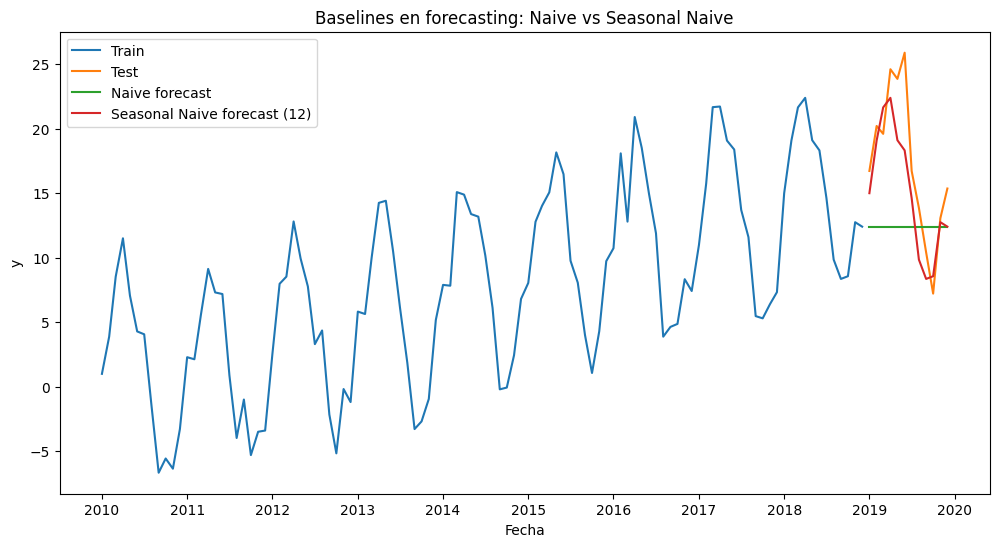

In [6]:
# Horizon
H = 12
train_ts = ts.iloc[:-H]
test_ts = ts.iloc[-H:]

# Naive: último valor
pred_naive = np.full(len(test_ts), train_ts.iloc[-1])

# Seasonal Naive (s=12): mismo mes del año anterior
pred_snaive = ts.shift(12).loc[test_ts.index].values

plt.figure(figsize=(12,6))
plt.plot(train_ts.index, train_ts.values, label="Train")
plt.plot(test_ts.index, test_ts.values, label="Test")
plt.plot(test_ts.index, pred_naive, label="Naive forecast")
plt.plot(test_ts.index, pred_snaive, label="Seasonal Naive forecast (12)")
plt.title("Baselines en forecasting: Naive vs Seasonal Naive")
plt.xlabel("Fecha")
plt.ylabel("y")
plt.legend()
plt.show()

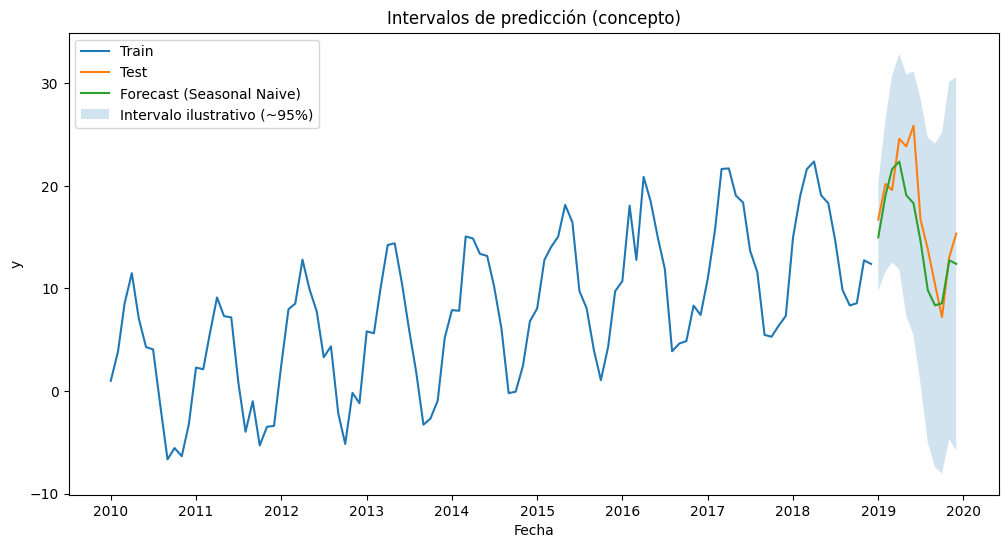

In [7]:
# Forecast baseline (Seasonal Naive) ya calculado:
pred = pred_snaive.copy()

# 1) Estimar sigma usando residuales del baseline Seasonal Naive en TRAIN
#    (alineamos índices para que ambas series tengan misma longitud)
residuals = (train_ts - train_ts.shift(12)).dropna()
sigma = residuals.std()

# 2) Intervalos ilustrativos que se abren con el horizonte
h = np.arange(1, len(test_ts) + 1)
band = 1.96 * sigma * np.sqrt(h)  # 95% aprox (ilustrativo)

lower = pred - band
upper = pred + band

plt.figure(figsize=(12,6))
plt.plot(train_ts.index, train_ts.values, label="Train")
plt.plot(test_ts.index, test_ts.values, label="Test")
plt.plot(test_ts.index, pred, label="Forecast (Seasonal Naive)")
plt.fill_between(test_ts.index, lower, upper, alpha=0.2, label="Intervalo ilustrativo (~95%)")
plt.title("Intervalos de predicción (concepto)")
plt.xlabel("Fecha")
plt.ylabel("y")
plt.legend()
plt.show()

## Ejemplos Forecast

# 0) Lectura de datos (desde tu repo)

Usamos enlaces **RAW** del repo para descarga directa:

- Airline: `https://raw.githubusercontent.com/josefrodrim/ML-course/main/data/airline_passengers.csv`
- Bitcoin: `https://raw.githubusercontent.com/josefrodrim/ML-course/main/data/bitcoin_daily.csv`

> Si corres el notebook dentro del repo, también usa lectura local `data/...`.

In [8]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

DATA_DIR = "data"
AIRLINE_LOCAL = os.path.join(DATA_DIR, "airline_passengers.csv")
BTC_LOCAL     = os.path.join(DATA_DIR, "bitcoin_daily.csv")

AIRLINE_RAW = "https://raw.githubusercontent.com/josefrodrim/ML-course/main/data/airline_passengers.csv"
BTC_RAW     = "https://raw.githubusercontent.com/josefrodrim/ML-course/main/data/bitcoin_daily.csv"

def read_csv_smart(local_path: str, raw_url: str):
    """Lee desde local si existe; si no, desde RAW GitHub."""
    if os.path.exists(local_path):
        return pd.read_csv(local_path), "local"
    return pd.read_csv(raw_url), "raw"

print("AIRLINE_LOCAL exists:", os.path.exists(AIRLINE_LOCAL))
print("BTC_LOCAL exists    :", os.path.exists(BTC_LOCAL))

AIRLINE_LOCAL exists: True
BTC_LOCAL exists    : True


# 1) Métricas (con fórmulas)

## MAE

$$
MAE = \frac{1}{n} \sum_{t=1}^{n} | y_t - \hat{y}_t |
$$

---

## RMSE

$$
RMSE = \sqrt{ \frac{1}{n} \sum_{t=1}^{n} ( y_t - \hat{y}_t )^2 }
$$

---

## sMAPE  
*(robusta cuando $y_t$ puede ser pequeño)*

$$
sMAPE =
\frac{100}{n}
\sum_{t=1}^{n}
\frac{
| y_t - \hat{y}_t |
}{
( | y_t | + | \hat{y}_t | ) / 2
}
$$

---

## MASE  
*(benchmark serio vs naive)*

$$
MASE =
\frac{
\frac{1}{n} \sum_{t=1}^{n} | y_t - \hat{y}_t |
}{
\frac{1}{n-1} \sum_{t=2}^{n} | y_t - y_{t-1} |
}
$$

**Interpretación:**

- MASE < 1 → Mejor que naive  
- MASE = 1 → Igual al naive  
- MASE > 1 → Peor que naive  

---

## Directional Accuracy (finanzas)

Mide el acierto del signo:

$$
DA =
\frac{1}{n}
\sum_{t=1}^{n}
\mathbf{1}
( \operatorname{sign}(y_t) = \operatorname{sign}(\hat{y}_t) )
$$

In [9]:

def mae(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def smape(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    denom = np.maximum((np.abs(y_true) + np.abs(y_pred)) / 2.0, eps)
    return float(100 * np.mean(np.abs(y_true - y_pred) / denom))

def mase(y_true, y_pred, y_train, eps=1e-9):
    y_train = np.asarray(y_train)
    scale = float(np.mean(np.abs(y_train[1:] - y_train[:-1])))
    scale = max(scale, eps)
    return float(mae(y_true, y_pred) / scale)

def directional_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return float(np.mean(np.sign(y_true) == np.sign(y_pred)))

def evaluate_forecast(y_true, y_pred, y_train_for_mase=None, name="model", add_diracc=False):
    out = {
        "model": name,
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "sMAPE_%": smape(y_true, y_pred),
    }
    if y_train_for_mase is not None:
        out["MASE"] = mase(y_true, y_pred, y_train_for_mase)
    if add_diracc:
        out["DirAcc"] = directional_accuracy(y_true, y_pred)
    return out

def plot_series(series: pd.Series, title: str, ylabel: str = "value"):
    plt.figure()
    plt.plot(series.index, series.values)
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel(ylabel)
    plt.show()

def plot_train_test_pred(train: pd.Series, test: pd.Series, pred, title: str):
    plt.figure()
    plt.plot(train.index, train.values, label="train")
    plt.plot(test.index, test.values, label="test")
    plt.plot(test.index, pred, label="forecast")
    plt.title(title)
    plt.legend()
    plt.show()

# PARTE A — Airline Passengers (mensual)

## Qué haremos
1. **Carga + QA**: verificar frecuencia, nulos y duplicados.
2. **EDA**: visualizar serie y estacionalidad por mes.
3. **STL**: descomponer tendencia/estacionalidad/residuo (opcional).
4. **ACF/PACF + ADF**: intuición para ARIMA/SARIMA (opcional).
5. **Baselines + ETS**: comparación base.
6. **SARIMA + intervalos**: modelo clásico robusto.
7. **Walk-forward**: evaluación industrial (robusta).

In [10]:

air_raw, air_src = read_csv_smart(AIRLINE_LOCAL, AIRLINE_RAW)
air_raw.columns = [c.strip().replace('"','') for c in air_raw.columns]

air_raw["Month"] = pd.to_datetime(air_raw["Month"])
air = air_raw.rename(columns={"Month":"date","Passengers":"y"}).copy()
air["y"] = pd.to_numeric(air["y"], errors="coerce")
air = air.sort_values("date").set_index("date")

print("Fuente:", air_src)
display(air.head(), air.tail())
print("Frecuencia inferida:", pd.infer_freq(air.index))
print("Nulos:\n", air.isnull().sum())
print("Duplicados idx:", air.index.duplicated().sum())

Fuente: local


,y
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


,y
date,
1960-08-01,606
1960-09-01,508
1960-10-01,461
1960-11-01,390
1960-12-01,432


Frecuencia inferida: MS
Nulos:
 y    0
dtype: int64
Duplicados idx: 0


**Celda:** EDA visual de la serie.

- Primera gráfica: patrón general (tendencia + amplitud).
- Segunda gráfica: estacionalidad por mes (cada línea = año).

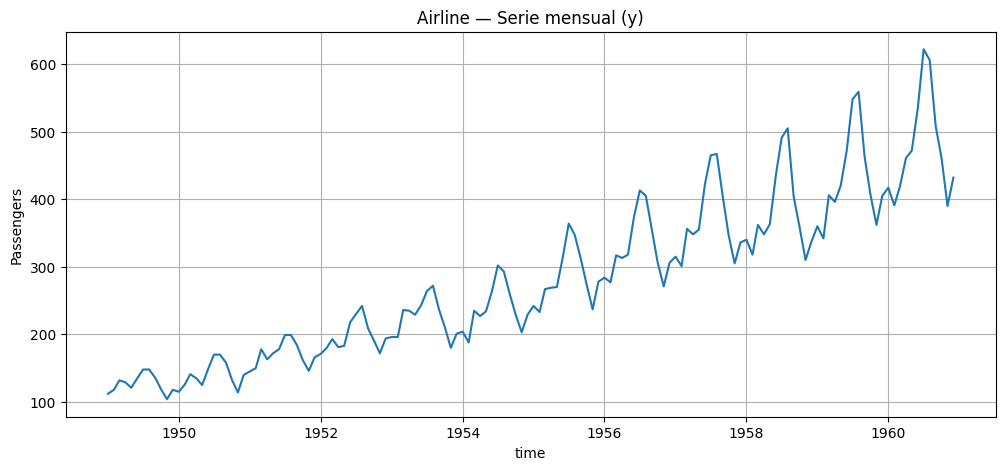

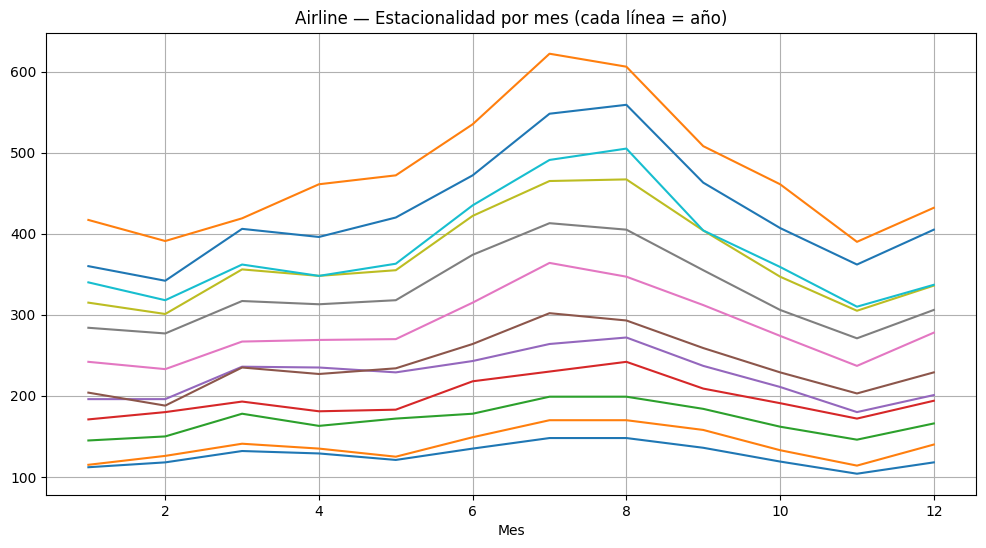

In [11]:

y = air["y"]
plot_series(y, "Airline — Serie mensual (y)", ylabel="Passengers")

tmp = y.to_frame("y")
tmp["year"] = tmp.index.year
tmp["month"] = tmp.index.month
pivot = tmp.pivot_table(index="month", columns="year", values="y", aggfunc="mean")

plt.figure(figsize=(12,6))
plt.plot(pivot.index, pivot.values)
plt.title("Airline — Estacionalidad por mes (cada línea = año)")
plt.xlabel("Mes")
plt.show()

## A1) STL 

Descomposición aditiva:

$$
y_t = T_t + S_t + E_t
$$

donde:

- $y_t$ : valor observado en el tiempo $t$  
- $T_t$ : componente de tendencia  
- $S_t$ : componente estacional  
- $E_t$ : componente de error (residuo)  

**Celda:** si está `statsmodels`, mostramos tendencia, estacionalidad y residuo.

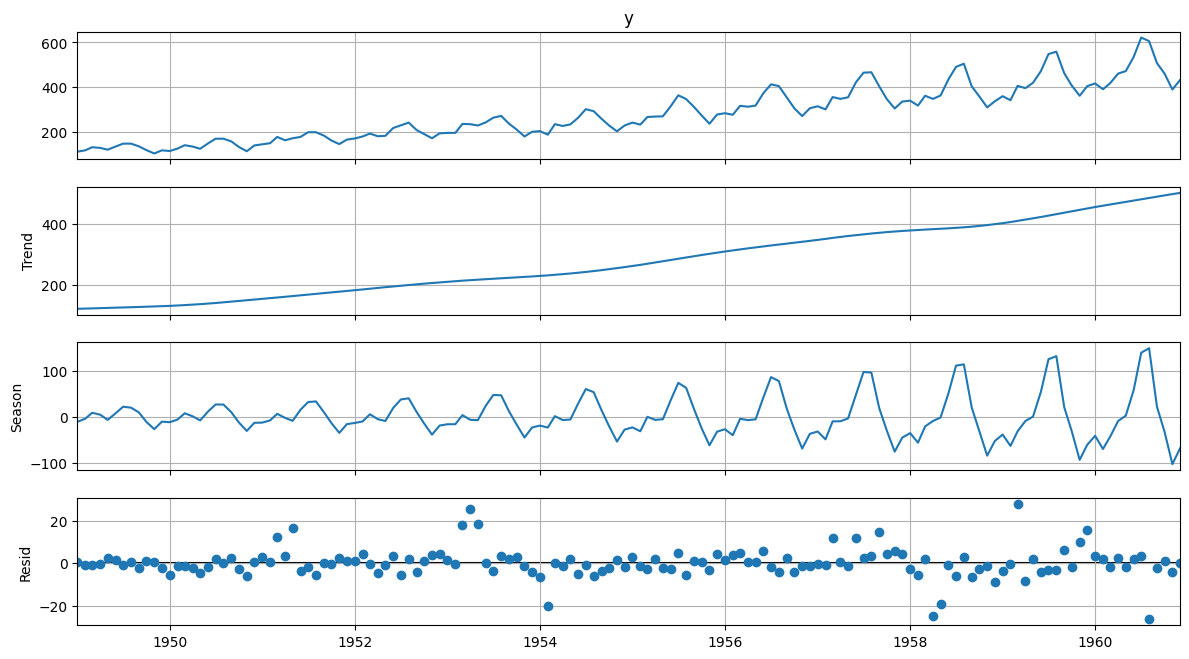

In [12]:

try:
    from statsmodels.tsa.seasonal import STL
    stl = STL(y, period=12, robust=True).fit()
    fig = stl.plot()
    fig.set_size_inches(12, 7)
    plt.show()
except Exception as e:
    print("STL no disponible (statsmodels). Error:", str(e)[:200])

## A2) ACF / PACF + ADF (opcional)

### ACF — Autocorrelation Function

Mide la correlación entre la serie y sus rezagos:

$$
\rho_k = \frac{\operatorname{Cov}(y_t, y_{t-k})}{\operatorname{Var}(y_t)}
$$

donde:

- $\rho_k$ = autocorrelación en el rezago $k$
- $y_t$ = valor en el tiempo $t$
- $y_{t-k}$ = valor rezagado $k$ periodos

---

### PACF — Partial Autocorrelation Function

Mide la correlación entre $y_t$ y $y_{t-k}$ **controlando** los rezagos intermedios:

$$
\phi_{kk} = \operatorname{Corr}(y_t, y_{t-k} \mid y_{t-1}, \dots, y_{t-k+1})
$$

Interpretación:

- ACF → ayuda a identificar el orden $q$ (MA)
- PACF → ayuda a identificar el orden $p$ (AR)

---

### ADF — Augmented Dickey-Fuller Test

Modelo base del test:

$$
\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{i=1}^{p} \delta_i \Delta y_{t-i} + \varepsilon_t
$$

donde:

- $\Delta y_t = y_t - y_{t-1}$
- $\gamma$ mide presencia de raíz unitaria
- $\varepsilon_t$ es ruido blanco

Hipótesis:

- $H_0$: La serie **no es estacionaria** (tiene raíz unitaria)
- $H_1$: La serie es estacionaria

Regla práctica:

- Si `p-value < 0.05` → se rechaza $H_0$ → serie más estacionaria
- Si `p-value ≥ 0.05` → no se rechaza $H_0$

---

**Celda siguiente:**  
Graficamos ACF y PACF, y ejecutamos ADF sobre:

1. Serie original $y_t$
2. Serie transformada $\log(y_t)$ diferenciada

<Figure size 1200x400 with 0 Axes>

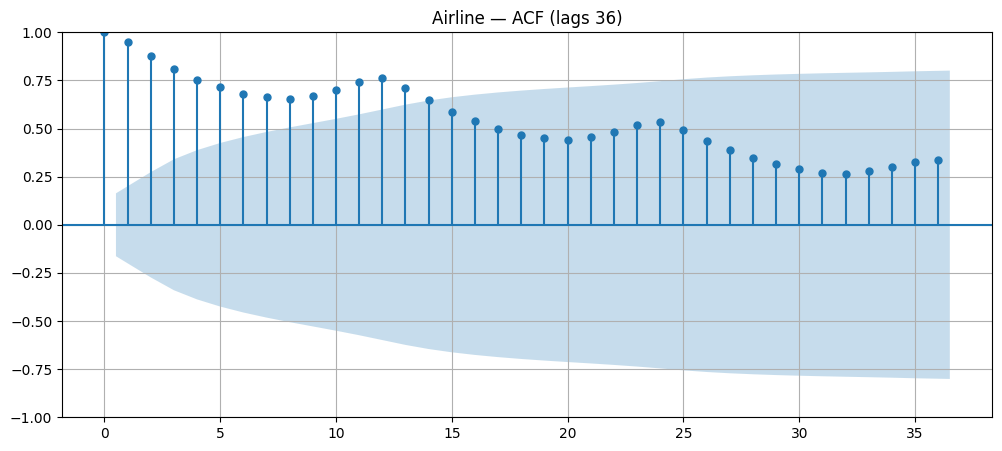

<Figure size 1200x400 with 0 Axes>

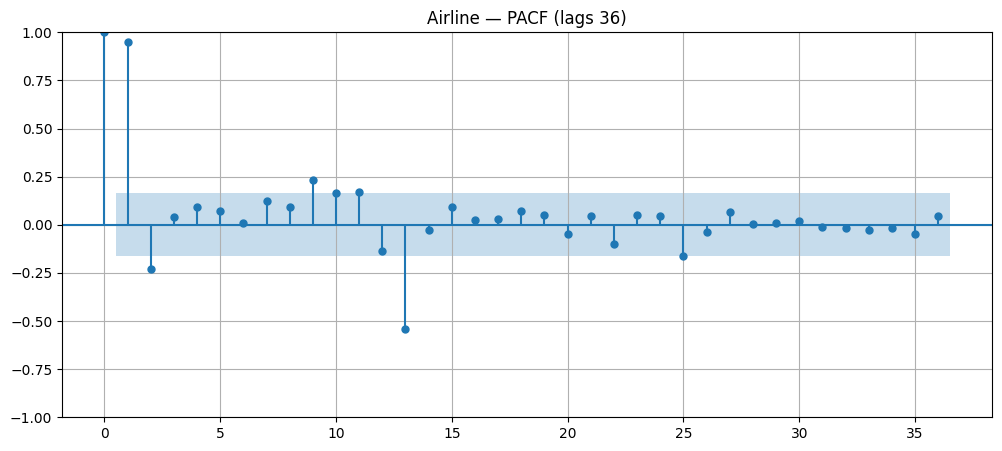

,name,ADF_stat,p_value,n_lags,n_obs
0,y (raw),0.815369,0.991880,13,130
1,log(y).diff(),-2.717131,0.071121,14,128


In [13]:

try:
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    from statsmodels.tsa.stattools import adfuller

    plt.figure(figsize=(12,4))
    plot_acf(y, lags=36)
    plt.title("Airline — ACF (lags 36)")
    plt.show()

    plt.figure(figsize=(12,4))
    plot_pacf(y, lags=36, method="ywm")
    plt.title("Airline — PACF (lags 36)")
    plt.show()

    def adf_test(series, name="series"):
        res = adfuller(series.dropna(), autolag="AIC")
        return {"name": name, "ADF_stat": res[0], "p_value": res[1], "n_lags": res[2], "n_obs": res[3]}

    adf_raw = adf_test(y, "y (raw)")
    adf_logdiff = adf_test(np.log(y).diff(), "log(y).diff()")
    display(pd.DataFrame([adf_raw, adf_logdiff]))
except Exception as e:
    print("ACF/PACF/ADF no disponible (statsmodels). Error:", str(e)[:200])

## A3) Baselines + ETS (single split)

**Split temporal:** últimos 12 meses como conjunto de test.  
Horizon:

$$
H = 12
$$

---

### Baselines

#### 1) Naive

Pronóstico constante igual al último valor observado:

$$
\hat{y}_{t+h} = y_t
$$

---

#### 2) Seasonal Naive (s = 12)

Usa el mismo valor del mismo mes del año anterior:

$$
\hat{y}_t = y_{t-12}
$$

---

#### 3) Moving Average (k)

Promedio de los últimos \(k\) valores:

$$
\hat{y}_{t+1} =
\frac{1}{k}
\sum_{i=0}^{k-1} y_{t-i}
$$

---

### ETS / Holt-Winters

Modelo exponencial con:

- Tendencia aditiva  
- Estacionalidad aditiva  
- Periodicidad:

$$
s = 12
$$

Forma conceptual del modelo aditivo:

$$
y_t = \ell_t + b_t + s_t + \varepsilon_t
$$

donde:

- $\ell_t$ = nivel
- $b_t$ = tendencia
- $s_t$ = estacionalidad
- $\varepsilon_t$ = error

/Users/josefrodriguez/repos/ML_course/clases_ml/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,model,MAE,RMSE,sMAPE_%,MASE
3,"ETS(add/add,12)",13.381971,16.980953,2.795830,0.555638
1,Seasonal Naive (12),47.833333,50.708316,10.571808,1.986107
2,MovingAvg(6),58.444444,76.773476,12.048534,2.426695
0,Naive,76.000000,102.976535,16.120845,3.155626


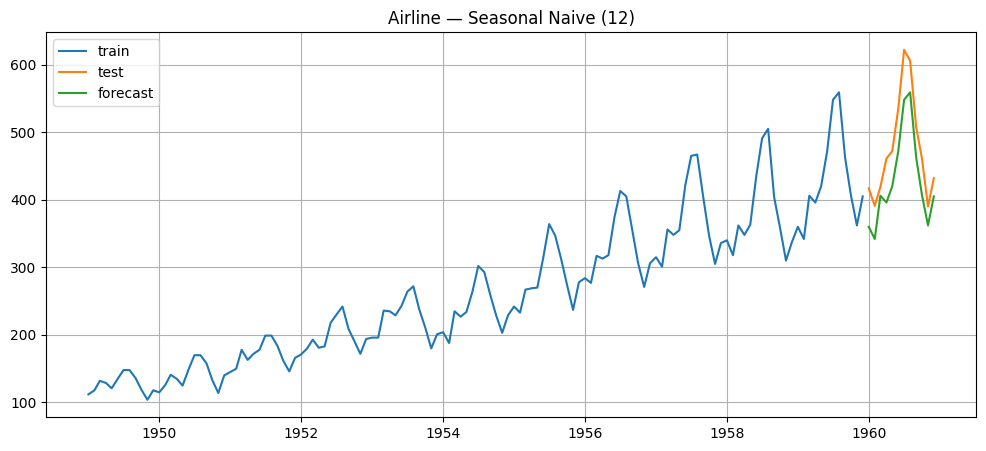

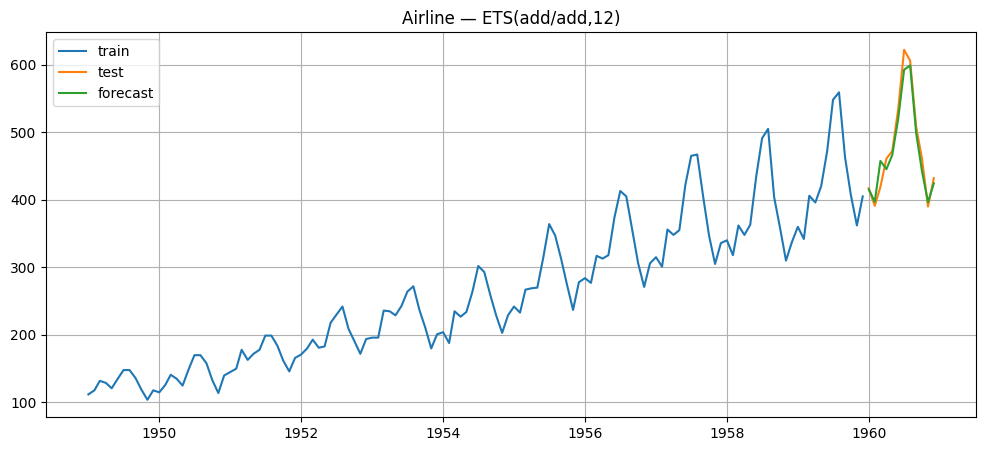

In [14]:

H = 12
train = y.iloc[:-H]
test  = y.iloc[-H:]

pred_snaive = y.shift(12).loc[test.index].values
pred_naive  = np.full(len(test), train.iloc[-1])

def moving_average_forecast(train_series: pd.Series, horizon_index, k=6):
    return np.full(len(horizon_index), train_series.iloc[-k:].mean())

pred_ma6 = moving_average_forecast(train, test.index, k=6)

scores = [
    evaluate_forecast(test.values, pred_naive,  y_train_for_mase=train.values, name="Naive"),
    evaluate_forecast(test.values, pred_snaive, y_train_for_mase=train.values, name="Seasonal Naive (12)"),
    evaluate_forecast(test.values, pred_ma6,    y_train_for_mase=train.values, name="MovingAvg(6)"),
]

pred_ets = None
try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    ets = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=12).fit(optimized=True)
    pred_ets = ets.forecast(len(test)).values
    scores.append(evaluate_forecast(test.values, pred_ets, y_train_for_mase=train.values, name="ETS(add/add,12)"))
except Exception as e:
    print("ETS no disponible (statsmodels). Error:", str(e)[:200])

air_scores_split = pd.DataFrame(scores).sort_values("MAE")
display(air_scores_split)

plot_train_test_pred(train, test, pred_snaive, "Airline — Seasonal Naive (12)")
if pred_ets is not None:
    plot_train_test_pred(train, test, pred_ets, "Airline — ETS(add/add,12)")

## A4) SARIMA + intervalos (single split)

SARIMA:
\[
ARIMA(p,d,q)\times(P,D,Q)_s
\]

Para estacionalidad mensual: \(s=12\).  
Usamos log-transform para estabilizar varianza y luego exponenciamos al final.

**Celda:** mini grid search por AIC y luego intervalos de predicción:
- 95% (alpha=0.05)
- 80% (alpha=0.20)

,model,MAE,RMSE,sMAPE_%,MASE
0,"SARIMA(1, 1, 0)x(0, 1, 0, 12)",34.98297,39.043622,7.084112,1.452542


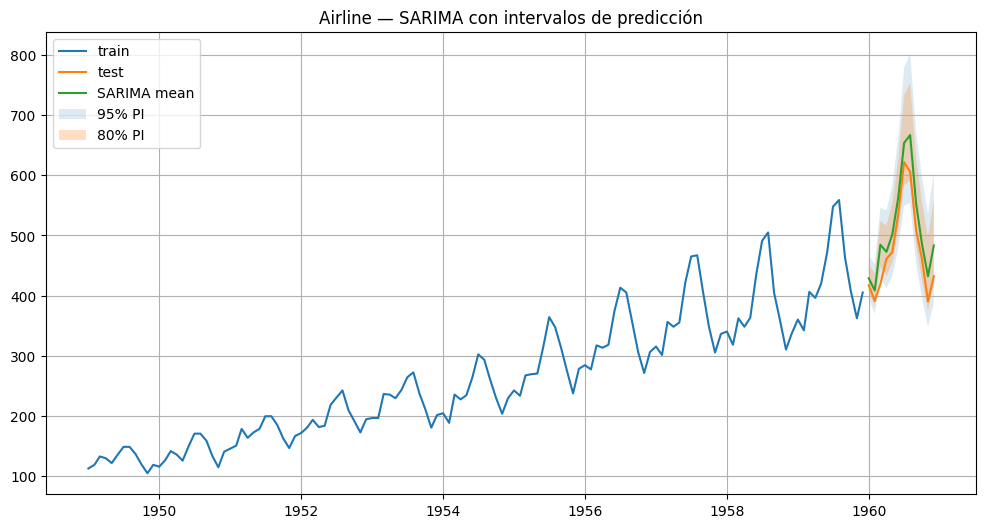

In [15]:

pred_sarima = None
sarima_name = None

try:
    import warnings
    warnings.filterwarnings("ignore")
    from statsmodels.tsa.statespace.sarimax import SARIMAX

    y_train_log = np.log(train)
    p = [0,1,2]; d=[1]; q=[0,1,2]
    P=[0,1]; D=[1]; Q=[0,1]; s=12

    best = {"aic": np.inf, "order": None, "sorder": None}
    for pi in p:
        for di in d:
            for qi in q:
                for Pi in P:
                    for Di in D:
                        for Qi in Q:
                            try:
                                m = SARIMAX(
                                    y_train_log,
                                    order=(pi,di,qi),
                                    seasonal_order=(Pi,Di,Qi,s),
                                    enforce_stationarity=False,
                                    enforce_invertibility=False
                                ).fit(disp=False)
                                if m.aic < best["aic"]:
                                    best = {"aic": m.aic, "order": (pi,di,qi), "sorder": (Pi,Di,Qi,s)}
                            except Exception:
                                pass

    sarima = SARIMAX(
        y_train_log,
        order=best["order"],
        seasonal_order=best["sorder"],
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    sarima_name = f"SARIMA{best['order']}x{best['sorder']}"
    fc = sarima.get_forecast(steps=len(test))
    mean_log = fc.predicted_mean
    pred_sarima = np.exp(mean_log).values

    sarima_score = evaluate_forecast(test.values, pred_sarima, y_train_for_mase=train.values, name=sarima_name)
    display(pd.DataFrame([sarima_score]))

    ci95 = fc.conf_int(alpha=0.05)
    ci80 = fc.conf_int(alpha=0.20)
    lower95, upper95 = np.exp(ci95.iloc[:,0].values), np.exp(ci95.iloc[:,1].values)
    lower80, upper80 = np.exp(ci80.iloc[:,0].values), np.exp(ci80.iloc[:,1].values)

    plt.figure(figsize=(12,6))
    plt.plot(train.index, train.values, label="train")
    plt.plot(test.index, test.values, label="test")
    plt.plot(test.index, pred_sarima, label="SARIMA mean")
    plt.fill_between(test.index, lower95, upper95, alpha=0.15, label="95% PI")
    plt.fill_between(test.index, lower80, upper80, alpha=0.25, label="80% PI")
    plt.title("Airline — SARIMA con intervalos de predicción")
    plt.legend()
    plt.show()
except Exception as e:
    print("SARIMA/intervalos no disponible. Error:", str(e)[:200])

## A5) Walk-forward 

En producción, re-entrenas periódicamente y predices el futuro con el pasado disponible.  
Walk-forward simula eso con **ventana creciente**.

**Modelos comparados**:
- Seasonal Naive (12)
- ETS(add/add,12)
- SARIMA (candidatos fijos para mantener runtime razonable)

**Salida**:
- tabla promedio de métricas por modelo
- evolución MAE (rolling mean) por tiempo

,MAE,RMSE,sMAPE_%,MASE
model,,,,
model,23.904109,26.900397,7.073453,1.307351


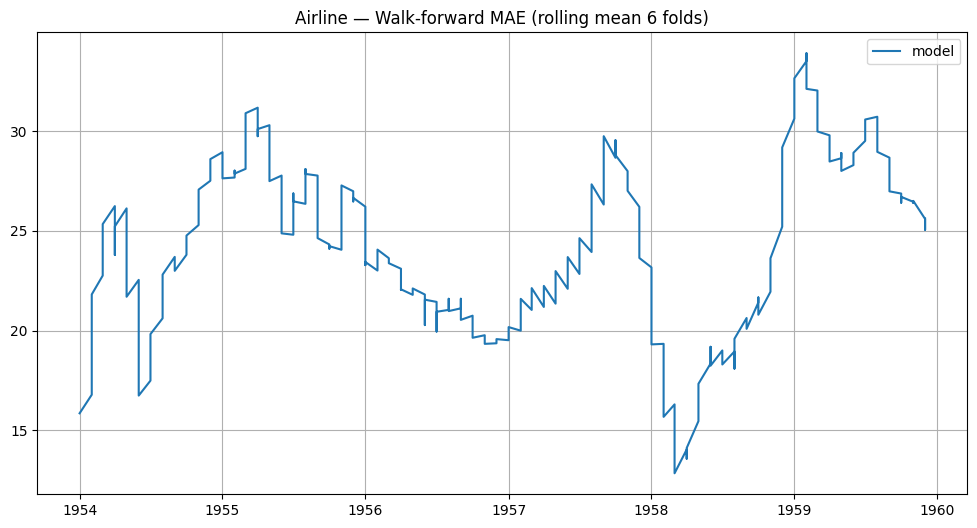

In [16]:

def walk_forward_airline(y: pd.Series, horizon=12, min_train=60):
    rows = []
    for end in range(min_train, len(y)-horizon+1):
        tr = y.iloc[:end]
        te = y.iloc[end:end+horizon]

        # Seasonal Naive
        snaive = y.shift(12).loc[te.index].values
        rows.append({"model":"Seasonal Naive (12)", "end_train": tr.index.max(), **evaluate_forecast(te.values, snaive, tr.values)})

        # ETS
        try:
            from statsmodels.tsa.holtwinters import ExponentialSmoothing
            ets = ExponentialSmoothing(tr, trend="add", seasonal="add", seasonal_periods=12).fit(optimized=True)
            p = ets.forecast(len(te)).values
            rows.append({"model":"ETS(add/add,12)", "end_train": tr.index.max(), **evaluate_forecast(te.values, p, tr.values)})
        except Exception:
            pass

        # SARIMA (candidatos fijos)
        try:
            from statsmodels.tsa.statespace.sarimax import SARIMAX
            tr_log = np.log(tr)
            cand = [
                ((0,1,1),(0,1,1,12)),
                ((1,1,1),(0,1,1,12)),
                ((1,1,0),(0,1,1,12)),
            ]
            best_aic = np.inf
            best_spec = None
            best_model = None
            for o, so in cand:
                try:
                    m = SARIMAX(tr_log, order=o, seasonal_order=so, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                    if m.aic < best_aic:
                        best_aic = m.aic
                        best_spec = (o, so)
                        best_model = m
                except Exception:
                    continue
            if best_model is not None:
                fc = best_model.forecast(steps=len(te))
                p = np.exp(fc).values
                rows.append({"model":f"SARIMA{best_spec[0]}x{best_spec[1]}", "end_train": tr.index.max(), **evaluate_forecast(te.values, p, tr.values)})
        except Exception:
            pass
    return pd.DataFrame(rows)

wf_air = walk_forward_airline(y, horizon=12, min_train=60)

summary = wf_air.groupby("model")[["MAE","RMSE","sMAPE_%","MASE"]].mean().sort_values("MAE")
display(summary)

plt.figure(figsize=(12,6))
for m in wf_air["model"].unique():
    s = wf_air[wf_air["model"]==m].set_index("end_train")["MAE"].rolling(6).mean()
    plt.plot(s.index, s.values, label=m)
plt.title("Airline — Walk-forward MAE (rolling mean 6 folds)")
plt.legend()
plt.show()

# PARTE B — Bitcoin (diario)

## Decisión profesional clave: retornos, no precio

En series financieras, predecir el precio directamente es difícil y no estacionario.  
Por ello modelamos **retornos logarítmicos**:

$$
r_t = \log \left( \frac{P_t}{P_{t-1}} \right)
$$

donde:

- $P_t$ = precio en el tiempo $t$
- $P_{t-1}$ = precio en el tiempo anterior

---

## Target a 1 día

Definimos como variable objetivo el retorno futuro:

$$
y_t = r_{t+1}
$$

Es decir, usamos información hasta el tiempo $t$ para predecir el retorno del siguiente día.

---

## Conversión a problema de ML tabular

Transformamos la serie temporal en un dataset supervisado con:

### Lags de retornos

$$
ret\_lag_k = r_{t-k}
$$

---

### Estadísticas rolling

Media móvil:

$$
\overline{r}_w = \frac{1}{w} \sum_{i=0}^{w-1} r_{t-i}
$$

Desviación estándar móvil:

$$
\sigma_w = std(r_{t-w+1}, ..., r_t)
$$

---

## Evaluación del modelo

Evaluamos con:

- MAE
- RMSE
- sMAPE
- MASE
- Directional Accuracy

---

## Backtest didáctico

Definimos posición según el signo de la predicción:

- Si $\hat{r}_{t+1} > 0$ → posición = +1  
- Si $\hat{r}_{t+1} < 0$ → posición = -1  
- Si $\hat{r}_{t+1} = 0$ → posición = 0  

Retorno de la estrategia con costos:

$$
R^{strategy}_{t+1}
=
position_t \cdot r_{t+1}
-
c \cdot | position_t - position_{t-1} |
$$

donde:

- $c$ = costo por trade (fee/slippage)
- $| position_t - position_{t-1} |$ mide cambios de posición

**Celda:** Carga + construcción de retornos log. (QA mínimo: columnas y tipos)

In [17]:

btc_raw, btc_src = read_csv_smart(BTC_LOCAL, BTC_RAW)
btc_raw.columns = [c.strip().lower() for c in btc_raw.columns]
btc_raw["date"] = pd.to_datetime(btc_raw["date"])
btc = btc_raw.sort_values("date").set_index("date").copy()

for c in ["open","high","low","close","volume"]:
    if c in btc.columns:
        btc[c] = pd.to_numeric(btc[c], errors="coerce")

if "close" not in btc.columns:
    raise ValueError("bitcoin_daily.csv debe contener columna 'close'")

btc["ret_log"] = np.log(btc["close"]).diff()

print("Fuente:", btc_src)
display(btc.head(), btc.tail())

Fuente: local


,open,high,low,close,ret_log
date,,,,,
2010-07-19,0.08584,0.09307,0.07723,0.08080,NaN
2010-07-20,0.08080,0.08181,0.07426,0.07474,-0.077962
2010-07-21,0.07474,0.07921,0.06634,0.07921,0.058087
2010-07-22,0.07921,0.08181,0.05050,0.05050,-0.450129
2010-07-23,0.05050,0.06767,0.05050,0.06262,0.215111


,open,high,low,close,ret_log
date,,,,,
2026-02-20,66908.8,68305.0,66330.5,67692.4,0.011228
2026-02-23,67693.3,67744.2,63882.6,64725.7,-0.044816
2026-02-24,64724.9,65025.8,62559.4,64154.3,-0.008867
2026-02-25,64159.7,69998.1,63891.2,68309.2,0.062753
2026-02-26,68449.5,68844.9,66660.8,66698.2,-0.023866


## B1) Feature engineering (lags + rolling + calendario)

### Lags

Definimos rezagos de los retornos como:

$$
ret\_lag_k = r_{t-k}
$$

donde:

- $k$ = número de periodos hacia atrás
- $r_{t-k}$ = retorno observado $k$ días antes

---

### Rolling mean (media móvil)

$$
mean_w =
\frac{1}{w}
\sum_{i=0}^{w-1}
r_{t-i}
$$

donde:

- $w$ = tamaño de ventana
- se promedian los últimos $w$ retornos

---

### Rolling standard deviation (volatilidad móvil)

$$
std_w =
\sqrt{
\frac{1}{w}
\sum_{i=0}^{w-1}
\left(
r_{t-i} - mean_w
\right)^2
}
$$

Esta variable captura la **volatilidad local** del mercado.

---

**Celda siguiente:**  
Construimos estas features y realizamos un **split temporal 80/20**:

- 80% datos iniciales → entrenamiento  
- 20% datos finales → test  

In [18]:

from typing import List

def make_features_bitcoin(df: pd.DataFrame,
                          target_horizon: int = 1,
                          lags: List[int] = [1,2,3,5,7,14],
                          roll_windows: List[int] = [7,14,30,60,90,180]) -> pd.DataFrame:
    out = df.copy()
    out["dow"] = out.index.dayofweek
    out["month"] = out.index.month

    for l in lags:
        out[f"ret_lag_{l}"] = out["ret_log"].shift(l)

    for w in roll_windows:
        out[f"ret_roll_mean_{w}"] = out["ret_log"].rolling(w).mean()
        out[f"ret_roll_std_{w}"]  = out["ret_log"].rolling(w).std()

    out["y_target"] = out["ret_log"].shift(-target_horizon)
    out = out.dropna()
    return out

btc_feat = make_features_bitcoin(btc, target_horizon=1)
target = "y_target"
feature_cols = [c for c in btc_feat.columns if c != target]

split = int(len(btc_feat) * 0.8)
train_df = btc_feat.iloc[:split]
test_df  = btc_feat.iloc[split:]

X_train = train_df[feature_cols]
X_test  = test_df[feature_cols]
y_train = train_df[target].values
y_test  = test_df[target].values

display(btc_feat.head())
print("Shape:", btc_feat.shape)

,open,high,low,close,ret_log,dow,month,ret_lag_1,ret_lag_2,ret_lag_3,...,ret_roll_std_14,ret_roll_mean_30,ret_roll_std_30,ret_roll_mean_60,ret_roll_std_60,ret_roll_mean_90,ret_roll_std_90,ret_roll_mean_180,ret_roll_std_180,y_target
date,,,,,,,,,,,,,,,,,,,,,
2011-03-28,0.8200,0.8500,0.7600,0.7990,-0.100870,0,3,0.019307,0.020040,0.049084,...,0.051520,-0.009735,0.056230,0.016606,0.084759,0.011342,0.086135,0.012730,0.090355,-0.008168
2011-03-29,0.7990,0.7997,0.7648,0.7925,-0.008168,1,3,-0.100870,0.019307,0.020040,...,0.051523,-0.009378,0.056204,0.016249,0.084818,0.011444,0.086106,0.013118,0.090113,-0.003539
2011-03-30,0.7925,0.7950,0.7660,0.7897,-0.003539,2,3,-0.008168,-0.100870,0.019307,...,0.045809,-0.009337,0.056208,0.016187,0.084832,0.011403,0.086113,0.012775,0.090059,-0.006479
2011-03-31,0.7897,0.8010,0.7680,0.7846,-0.006479,3,3,-0.003539,-0.008168,-0.100870,...,0.043816,-0.009393,0.056204,0.016135,0.084845,0.011449,0.086102,0.015240,0.083123,-0.013473
2011-04-01,0.7846,0.7970,0.7741,0.7741,-0.013473,4,4,-0.006479,-0.003539,-0.008168,...,0.043231,-0.004982,0.049977,0.014723,0.084617,0.011126,0.086141,0.013970,0.081788,-0.129608


Shape: (3859, 26)


## B2) Modelado (Linear + Boosting opcional)

**Celda:** armamos pipeline con:
- ColumnTransformer (num passthrough + OneHot para calendario)
- LinearRegression (baseline ML)
- LightGBM/XGBoost (si está instalado)

Luego evaluamos con métricas + Directional Accuracy.

In [19]:

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

cat_cols = ["dow","month"]
num_cols = [c for c in feature_cols if c not in cat_cols]

preprocess = ColumnTransformer([
    ("num","passthrough",num_cols),
    ("cat",OneHotEncoder(handle_unknown="ignore"),cat_cols),
])

lin = Pipeline([("prep",preprocess),("model",LinearRegression())])

boost = None
boost_name = None
try:
    from lightgbm import LGBMRegressor
    boost = Pipeline([("prep",preprocess),("model",LGBMRegressor(
        n_estimators=1500, learning_rate=0.03, num_leaves=63,
        subsample=0.8, colsample_bytree=0.8, random_state=42
    ))])
    boost_name = "LightGBM"
except Exception:
    try:
        from xgboost import XGBRegressor
        boost = Pipeline([("prep",preprocess),("model",XGBRegressor(
            n_estimators=1500, learning_rate=0.03, max_depth=5,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, random_state=42
        ))])
        boost_name = "XGBoost"
    except Exception:
        boost = None

use_model = boost if boost is not None else lin
use_name = boost_name if boost is not None else "Linear Regression"

use_model.fit(X_train, train_df[target])
pred = use_model.predict(X_test)

display(pd.DataFrame([evaluate_forecast(y_test, pred, y_train_for_mase=y_train, name=use_name, add_diracc=True)]))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000323 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5899
[LightGBM] [Info] Number of data points in the train set: 3087, number of used features: 40
[LightGBM] [Info] Start training from score 0.003333


,model,MAE,RMSE,sMAPE_%,MASE,DirAcc
0,LightGBM,0.02532,0.034222,145.816658,0.527224,0.514249


## B3) Backtest didáctico con costos y posiciones -1 / 0 / +1

### Señal de trading

Definimos la posición según el signo de la predicción:

Si

$$
\hat{r}_{t+1} > 0
$$

entonces:

$$
position_t = +1
$$

Si

$$
\hat{r}_{t+1} < 0
$$

entonces:

$$
position_t = -1
$$

Si

$$
\hat{r}_{t+1} = 0
$$

entonces:

$$
position_t = 0
$$

---

### Costo por trade (fee / slippage)

Cada cambio de posición incurre un costo fijo:

$$
c
$$

Número de cambios de posición:

$$
| position_t - position_{t-1} |
$$

Nota:

- Cambiar de -1 a +1 implica 2 cambios.
- Cambiar de 0 a +1 implica 1 cambio.

---

### Retorno de la estrategia

El retorno neto con costos es:

$$
R_{t+1}^{strategy}
=
position_t \cdot r_{t+1}
-
c \cdot | position_t - position_{t-1} |
$$

donde:

- $r_{t+1}$ = retorno real del mercado
- $position_t$ = posición tomada en el tiempo $t$
- $c$ = costo por transacción

---

**Celda siguiente:**  

- Graficamos la equity curve  
- Calculamos KPIs didácticos:
  - Sharpe Ratio
  - Retorno acumulado
  - Máximo Drawdown
  - Número de trades

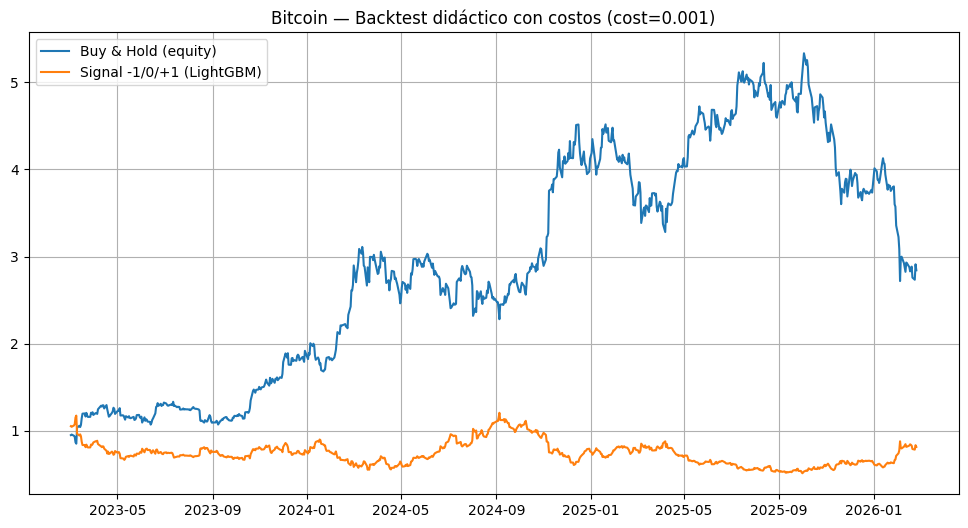

,Strategy,Sharpe,CumReturn,MaxDrawdown,Trades
0,Buy & Hold,0.721039,1.842200,-0.490316,0
1,Signal -1/0/+1 (LightGBM),-0.141847,-0.185842,-0.575918,439


In [20]:

signal = np.sign(pred).astype(int)

r_true = y_test  # log-returns reales

cost_per_trade = 0.001  # 10 bps (didáctico)

pos = signal.copy()
pos_prev = np.r_[0, pos[:-1]]
trades = np.abs(pos - pos_prev)

r_strat = pos * r_true - cost_per_trade * trades

equity_bh = np.exp(np.cumsum(r_true))
equity_strat = np.exp(np.cumsum(r_strat))

plt.figure(figsize=(12,6))
plt.plot(test_df.index, equity_bh, label="Buy & Hold (equity)")
plt.plot(test_df.index, equity_strat, label=f"Signal -1/0/+1 ({use_name})")
plt.title(f"Bitcoin — Backtest didáctico con costos (cost={cost_per_trade})")
plt.legend()
plt.show()

def sharpe(returns, eps=1e-12):
    mu = np.mean(returns)
    sd = np.std(returns)
    return float(mu / (sd + eps) * np.sqrt(252))

def max_drawdown(equity):
    peak = np.maximum.accumulate(equity)
    dd = equity / peak - 1.0
    return float(dd.min())

kpis = pd.DataFrame([{
    "Strategy": "Buy & Hold",
    "Sharpe": sharpe(r_true),
    "CumReturn": float(equity_bh[-1] - 1.0),
    "MaxDrawdown": max_drawdown(equity_bh),
    "Trades": 0
},{
    "Strategy": f"Signal -1/0/+1 ({use_name})",
    "Sharpe": sharpe(r_strat),
    "CumReturn": float(equity_strat[-1] - 1.0),
    "MaxDrawdown": max_drawdown(equity_strat),
    "Trades": int(trades.sum())
}])

display(kpis)

# Cierre (texto para tu slide final)

### Airline
- Estacionalidad anual fuerte → **Seasonal Naive** es baseline obligatorio.
- ETS y SARIMA suelen mejorar; SARIMA permite **intervalos** para comunicar incertidumbre.
- Walk-forward muestra desempeño más realista que un solo split.

### Bitcoin
- Modelar retornos es más correcto que modelar precios.
- Comparar contra baselines honestos y evaluar con walk-forward.
- Backtest con costos enseña por qué un “buen paper” no siempre implica utilidad práctica.